In [1]:
import collections
import os
import json

import functorch.dim
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import rasterio
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchinfo
import torchvision
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix, classification_report
from torch.optim.lr_scheduler import StepLR
from torch.utils.data import Dataset, DataLoader, random_split
from torchinfo import summary
from torchvision import datasets, transforms
from tqdm import tqdm
from sklearn.metrics import f1_score
from collections import Counter

In [2]:
print("torch version : ", torch.__version__)
print("torchvision version : ", torchvision.__version__)
print("torchinfo version : ", torchinfo.__version__)
print("numpy version : ", np.__version__)
print("matplotlib version : ", matplotlib.__version__)
print("rasterio version : ", rasterio.__version__)



torch version :  2.10.0+cu128
torchvision version :  0.25.0+cu128
torchinfo version :  1.8.0
numpy version :  2.4.6
matplotlib version :  3.10.0
rasterio version :  1.5.0


In [3]:
if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"

print(f"Using {device} device.")

Using cuda device.


Since we are working with dataset that is made of 13 channeled tif files (in comparison with default RGB images) we have to create our own dataset class because pytroch's ImageFolder takes only images as inputs.A custom Dataset class must implement three functions: __init__, __len__, and __getitem__. Lets implement Dataset class:

In [4]:
class EuroSATdataset(Dataset):
    def __init__(self, csv_file, root_dir,label_map_path, transform=None):
        self.data = pd.read_csv(csv_file)
        self.root = root_dir
        self.transform = transform

        with open(label_map_path) as f:
            label_map = json.load(f)
        self.class_to_idx = label_map
        self.classes = [None] * len(label_map)
        for name, idx in label_map.items():
            self.classes[idx] = name
    def __len__(self):
        return len(self.data)
    def __getitem__(self, idx):
        row = self.data.iloc[idx] 
        path = os.path.join(self.root,row["Filename"])
        with rasterio.open(path) as src:
            img = torch.from_numpy(src.read()).float()
        if self.transform:
            img = self.transform(img)
        label = int(row["Label"])
        return img, label 


In [5]:
Train_dataset = EuroSATdataset("/kaggle/input/datasets/apollo2506/eurosat-dataset/EuroSATallBands/train.csv","/kaggle/input/datasets/apollo2506/eurosat-dataset/EuroSATallBands","/kaggle/input/datasets/apollo2506/eurosat-dataset/EuroSATallBands/label_map.json")


Lets check our classes and shape of one tensor

In [6]:
check = Train_dataset.__getitem__(1)[0]
print(f"Shape of one data we have:{check.shape}")
print(f"Classes we have:{Train_dataset.classes}")

Shape of one data we have:torch.Size([13, 64, 64])
Classes we have:['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


In [7]:
train_loader = DataLoader(Train_dataset,batch_size=32,shuffle=True,num_workers=4,pin_memory=True,persistent_workers=True,prefetch_factor=4)
first_batch = next(iter(train_loader))
print(f"Shape of one batch:{first_batch[0].shape}")


Shape of one batch:torch.Size([32, 13, 64, 64])


In [8]:
def get_mean_std(loader):
    channels_sum, channels_squared_sum, num_batches = 0,0,0
    for data,_ in tqdm(loader,desc="computing mean and standard deviation",leave=False):
        channels_sum+=torch.mean(data,dim =[0,2,3])
        channels_squared_sum+=torch.mean(data ** 2,dim =[0,2,3])
        num_batches+=1
    mean = channels_sum/num_batches
    std =(channels_squared_sum/num_batches-mean**2)**0.5
    return mean,std


Lets check mean and std of train dataset so we can normalize datasets appropriately 

In [9]:
mean,std = get_mean_std(train_loader)
print(f"Mean: {mean}")
print(f"Standard deviation: {std}")

Mean: tensor([1353.9154, 1115.3624, 1033.2842,  934.7294, 1180.4473, 1964.9119,
        2326.8376, 2254.5574,  723.2913,   13.1450, 1780.3672, 1097.9852,
        2543.1528])
Standard deviation: tensor([ 243.3036,  330.1577,  395.2034,  592.9288,  574.9088,  885.2385,
        1113.6155, 1142.7491,  404.9419,    9.1850, 1026.2557,  764.8311,
        1267.5537])


In [10]:
norm_transform = transforms.Normalize(mean,std)

In [11]:
norm_train_dataset = EuroSATdataset("/kaggle/input/datasets/apollo2506/eurosat-dataset/EuroSATallBands/train.csv","/kaggle/input/datasets/apollo2506/eurosat-dataset/EuroSATallBands","/kaggle/input/datasets/apollo2506/eurosat-dataset/EuroSATallBands/label_map.json",transform=norm_transform)
norm_train_loader = DataLoader(norm_train_dataset,batch_size=32,shuffle=True,num_workers=4,pin_memory=True,persistent_workers=True,prefetch_factor=4)
print(get_mean_std(norm_train_loader))

(tensor([ 2.7909e-04,  2.5740e-04,  2.0714e-04,  2.2605e-04,  1.9756e-04,
         2.1636e-05,  6.0935e-06,  6.2873e-06, -2.4709e-05,  2.7273e-05,
         9.5108e-05,  9.5427e-05,  1.2939e-05]), tensor([1.0000, 1.0001, 1.0001, 1.0002, 1.0002, 1.0000, 1.0000, 1.0000, 0.9999,
        1.0000, 1.0000, 1.0000, 1.0000]))


In [12]:
norm_val_dataset = EuroSATdataset("/kaggle/input/datasets/apollo2506/eurosat-dataset/EuroSATallBands/validation.csv","/kaggle/input/datasets/apollo2506/eurosat-dataset/EuroSATallBands","/kaggle/input/datasets/apollo2506/eurosat-dataset/EuroSATallBands/label_map.json",transform=norm_transform)
val_loader = DataLoader(norm_val_dataset,batch_size=32,shuffle=False,num_workers=4,pin_memory=True,persistent_workers=True,prefetch_factor=4)

Dataset is already divided into val,test,train parts so we keep it that way

In [13]:
length_val = len(norm_val_dataset)
length_train = len(norm_train_dataset)
length_dataset = length_val+length_train
percent_train = np.round(100 * length_train / length_dataset, 2)
percent_val = np.round(100 * length_val / length_dataset, 2)
print(f"Train data is {percent_train}% of full data")
print(f"Validation data is {percent_val}% of full data")

Train data is 77.78% of full data
Validation data is 22.22% of full data


In [14]:
def class_counts(dataset):
    c = collections.Counter(x[1] for x in tqdm(dataset))
    class_to_index = dataset.class_to_idx
    return pd.Series({cat: c[idx] for cat, idx in class_to_index.items()})


In [15]:
train_class_distribution= class_counts(norm_train_dataset)

100%|██████████| 19317/19317 [01:18<00:00, 246.43it/s]


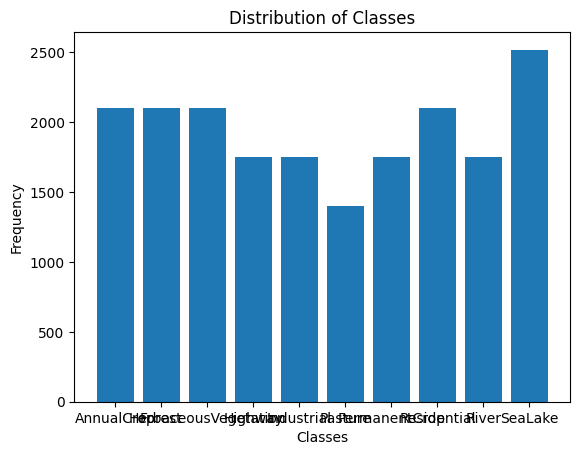

In [16]:
categories = norm_train_dataset.classes
values = train_class_distribution
plt.bar(categories,values)
plt.xlabel("Classes")
plt.ylabel("Frequency")
plt.title("Distribution of Classes")
plt.show()

It seems our biggest class (SeaLake, 2517) is only about 1.8× our smallest (Pasture, 1400) and it is not worth to undersample the data as imbalance is not that dramatic./

100%|██████████| 5519/5519 [02:04<00:00, 44.32it/s]


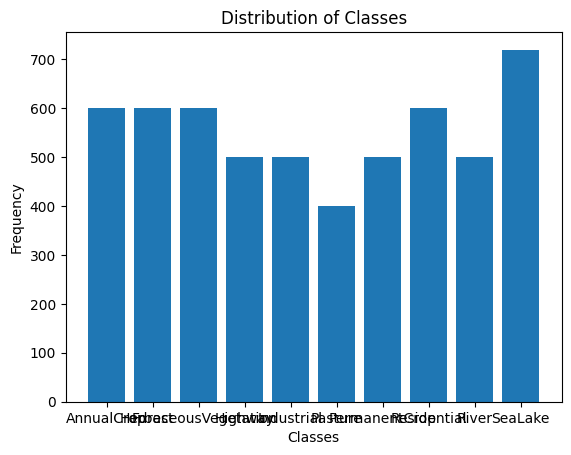

In [17]:
val_class_distribution = class_counts(norm_val_dataset)
plt.bar(categories,val_class_distribution)
plt.xlabel("Classes")
plt.ylabel("Frequency")
plt.title("Distribution of Classes")
plt.show()

Validation dataset also looks good!

Lets create our model. It will contain 4 convolutional layers and batch_normalize and maxpooling layers after each convolution. 

In [18]:
model = torch.nn.Sequential()
model.append(nn.Conv2d(in_channels=13,out_channels=64,kernel_size=3,padding=1,bias=False))
model.append(nn.BatchNorm2d(num_features=64))
model.append(nn.ReLU())
model.append(nn.MaxPool2d(kernel_size=2,stride=2))
model.append(nn.Conv2d(in_channels=64,out_channels=128,kernel_size=3,padding=1,bias=False))
model.append(nn.BatchNorm2d(num_features=128))
model.append(nn.BatchNorm2d(num_features=128))
model.append(nn.ReLU())
model.append(nn.MaxPool2d(kernel_size=2,stride=2))
model.append(nn.Conv2d(in_channels=128,out_channels=256,kernel_size=3,padding=1,bias=False))
model.append(nn.BatchNorm2d(num_features=256))
model.append(nn.ReLU())
model.append(nn.MaxPool2d(kernel_size=2,stride=2))
model.append(nn.Conv2d(in_channels=256,out_channels=512,kernel_size=3,padding=1,bias=False))
model.append(nn.BatchNorm2d(num_features=512))
model.append(nn.ReLU())
model.append(nn.MaxPool2d(kernel_size=2,stride=2))
model.append(nn.Flatten())
model.append(nn.Dropout(p=0.5))
model.append(nn.Linear(in_features=8192,out_features=10))



Sequential(
  (0): Conv2d(13, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU()
  (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (4): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (5): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (6): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (7): ReLU()
  (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (9): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (10): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (11): ReLU()
  (12): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (13): Conv2d(256, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)


In [19]:
summary(model,input_size=(32,13,64,64))

Layer (type:depth-idx)                   Output Shape              Param #
Sequential                               [32, 10]                  --
├─Conv2d: 1-1                            [32, 64, 64, 64]          7,488
├─BatchNorm2d: 1-2                       [32, 64, 64, 64]          128
├─ReLU: 1-3                              [32, 64, 64, 64]          --
├─MaxPool2d: 1-4                         [32, 64, 32, 32]          --
├─Conv2d: 1-5                            [32, 128, 32, 32]         73,728
├─BatchNorm2d: 1-6                       [32, 128, 32, 32]         256
├─BatchNorm2d: 1-7                       [32, 128, 32, 32]         256
├─ReLU: 1-8                              [32, 128, 32, 32]         --
├─MaxPool2d: 1-9                         [32, 128, 16, 16]         --
├─Conv2d: 1-10                           [32, 256, 16, 16]         294,912
├─BatchNorm2d: 1-11                      [32, 256, 16, 16]         512
├─ReLU: 1-12                             [32, 256, 16, 16]         --

In [20]:
loss_fn = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(),lr=0.001)

Lets create train,predict and score functions

In [21]:
def train_epoch(model,optimizer,loss_fn,data_loader,device):
    training_loss = 0.0
    model.train()
    for inputs,targets in tqdm(data_loader,desc="training",leave=False):
        optimizer.zero_grad()
        inputs = inputs.to(device)
        targets = targets.to(device)
        outputs = model(inputs)
        loss = loss_fn(outputs,targets)
        loss.backward()
        optimizer.step()
        training_loss += loss.data.item()*inputs.size(0)
    return training_loss/len(data_loader.dataset)

In [22]:
def predict(model,data_loader,device):
    all_probs=torch.tensor([]).to(device)
    model.eval()
    with torch.no_grad():
        for inputs,targets in tqdm(data_loader,desc="predicting",leave=False):
            inputs = inputs.to(device)
            output=model(inputs)
            probs=F.softmax(output,dim=1)
            all_probs = torch.cat((all_probs,probs),dim=0)
    return all_probs


In [23]:
def score(model, data_loader, loss_fn, device):
    total_loss = 0
    total_correct = 0
    all_preds = []
    all_targets = []

    model.eval()
    with torch.no_grad():
        for inputs, targets in tqdm(data_loader, desc="Scoring", leave=False):
            inputs  = inputs.to(device)
            targets = targets.to(device)
            output  = model(inputs)

            loss = loss_fn(output, targets)
            total_loss += loss.item() * inputs.size(0)

            preds = torch.argmax(output, dim=1)
            correct = torch.eq(preds, targets)
            total_correct += torch.sum(correct).item()

            # Collect for F1 (move to CPU to avoid building a big GPU tensor)
            all_preds.append(preds.cpu())
            all_targets.append(targets.cpu())

    n_observations = len(data_loader.dataset)         # ← bug fix, see below
    average_loss   = total_loss / n_observations
    accuracy       = total_correct / n_observations

    all_preds   = torch.cat(all_preds).numpy()
    all_targets = torch.cat(all_targets).numpy()
    macro_f1    = f1_score(all_targets, all_preds, average="macro")

    return average_loss, accuracy, macro_f1

In [24]:
model=model.to(device)

 lets add learning rate scheduler. We will be training our model for 60 epochs so i think step size 20 and gamma factor 0.1 works in our case

In [25]:
step_size = 20
gamma = 0.1
scheduler = StepLR(optimizer, step_size=step_size, gamma=gamma)

In [26]:
def early_stopping(validation_f1, best_val_f1, counter, patience=5):

    stop = False

    if validation_f1 > best_val_f1:                    # F1: higher = better
        counter = 0
    else:
        counter += 1

    if counter >= patience:
        stop = True

    return counter, stop

Lets add checkpointing to save the model that produces the best f1 score.  Model may start overfit at later epochs so it is better to save best one.


In [27]:
def checkpointing(validation_f1, best_val_f1, model, optimizer, save_path,epoch):
    if validation_f1 > best_val_f1:
        torch.save(
            {
                "epoch": epoch,
      "model_state_dict": model.state_dict(),
      "optimizer_state_dict": optimizer.state_dict(),
      "scheduler_state_dict": scheduler.state_dict() if scheduler else None,
      "best_val_f1": best_val_f1,
            },
            save_path,
        )
        print(f"Checkpoint saved with validation F1 {validation_f1:.4f}")

In [28]:
def train(
    model,
    optimizer,
    loss_fn,
    train_loader,
    val_loader,
    epochs,
    device,
    scheduler=None,
    checkpoint_path=None,
    early_stopping_fn=None,         # renamed to avoid collision with the function
):
    # Track model progress over epochs
    train_losses = []
    train_accuracies = []
    train_f1s = []
    val_losses = []
    val_accuracies = []
    val_f1s = []
    learning_rates = []

    # Track best F1 for checkpointing + early stopping
    best_val_f1 = 0.0               # F1 starts low, we want it to climb
    early_stopping_counter = 0

    print("Model evaluation before start of training...")
    train_loss, train_accuracy, train_f1 = score(model, train_loader, loss_fn, device)
    train_losses.append(train_loss)
    train_accuracies.append(train_accuracy)
    train_f1s.append(train_f1)

    validation_loss, validation_accuracy, validation_f1 = score(model, val_loader, loss_fn, device)
    val_losses.append(validation_loss)
    val_accuracies.append(validation_accuracy)
    val_f1s.append(validation_f1)

    for epoch in range(1, epochs + 1):
        print("\n")
        print(f"Starting epoch {epoch}/{epochs}")

        # Train one epoch
        train_epoch(model, optimizer, loss_fn, train_loader, device)

        # Evaluate on training set (eval mode)
        train_loss, train_accuracy, train_f1 = score(model, train_loader, loss_fn, device)
        train_losses.append(train_loss)
        train_accuracies.append(train_accuracy)
        train_f1s.append(train_f1)

        # Evaluate on validation set
        validation_loss, validation_accuracy, validation_f1 = score(model, val_loader, loss_fn, device)
        val_losses.append(validation_loss)
        val_accuracies.append(validation_accuracy)
        val_f1s.append(validation_f1)

        print(f"Epoch: {epoch}")
        print(f"Training   — loss: {train_loss:.4f}, acc: {train_accuracy*100:.2f}%, F1: {train_f1:.4f}")
        print(f"Validation — loss: {validation_loss:.4f}, acc: {validation_accuracy*100:.2f}%, F1: {validation_f1:.4f}")

        # Log LR (use the one applied this epoch), then step scheduler
        lr = optimizer.param_groups[0]["lr"]
        learning_rates.append(lr)
        if scheduler:
            scheduler.step()

        # Checkpoint if val F1 improved
        if checkpoint_path:
            checkpointing(
                validation_f1, best_val_f1, model, optimizer, checkpoint_path,epoch
            )

        # Early stopping
        if early_stopping_fn:
            early_stopping_counter, stop = early_stopping_fn(
                validation_f1, best_val_f1, early_stopping_counter
            )
            if stop:
                print(f"Early stopping triggered after {epoch} epochs")
                break

        # Update best AFTER checkpointing/early-stopping (they need the old best to compare)
        if validation_f1 > best_val_f1:
            best_val_f1 = validation_f1

    return (
        learning_rates,
        train_losses,
        val_losses,
        train_accuracies,
        val_accuracies,
        train_f1s,
        val_f1s,
        epoch
    )

In [29]:
epochs = 60
train_results = train(model,optimizer,loss_fn,norm_train_loader,val_loader,epochs=epochs,device=device, scheduler=scheduler, checkpoint_path="/kaggle/working/checkpoint.pt",early_stopping_fn=early_stopping)



Model evaluation before start of training...




Starting epoch 1/60


Epoch: 1
Training   — loss: 0.3944, acc: 86.80%, F1: 0.8619
Validation — loss: 0.4171, acc: 86.65%, F1: 0.8598
Checkpoint saved with validation F1 0.8598


Starting epoch 2/60


Epoch: 2
Training   — loss: 0.5190, acc: 88.54%, F1: 0.8839
Validation — loss: 0.5392, acc: 87.37%, F1: 0.8715
Checkpoint saved with validation F1 0.8715


Starting epoch 3/60


Epoch: 3
Training   — loss: 0.2064, acc: 93.19%, F1: 0.9274
Validation — loss: 0.2522, acc: 91.68%, F1: 0.9118
Checkpoint saved with validation F1 0.9118


Starting epoch 4/60


...

Epoch: 32
Training   — loss: 0.0031, acc: 99.93%, F1: 0.9992
Validation — loss: 0.0678, acc: 98.33%, F1: 0.9822


Starting epoch 33/60


Epoch: 33
Training   — loss: 0.0035, acc: 99.92%, F1: 0.9992
Validation — loss: 0.0691, acc: 98.13%, F1: 0.9800


Starting epoch 34/60


Epoch: 34
Training   — loss: 0.0027, acc: 99.94%, F1: 0.9993
Validation — loss: 0.0603, acc: 98.33%, F1: 0.9821


Starting epoch 35/60


Epoch: 35
Training   — loss: 0.0036, acc: 99.89%, F1: 0.9988
Validation — loss: 0.0699, acc: 98.04%, F1: 0.9791


Starting epoch 36/60


Epoch: 36
Training   — loss: 0.0025, acc: 99.95%, F1: 0.9994
Validation — loss: 0.0665, acc: 98.30%, F1: 0.9817
Early stopping triggered after 36 epochs


Now the training is over, lets analyze model on test data

In [30]:
ckpt = torch.load("/kaggle/working/checkpoint.pt")
model.load_state_dict(ckpt["model_state_dict"])
norm_test_dataset = EuroSATdataset("/kaggle/input/datasets/apollo2506/eurosat-dataset/EuroSATallBands/test.csv","/kaggle/input/datasets/apollo2506/eurosat-dataset/EuroSATallBands","/kaggle/input/datasets/apollo2506/eurosat-dataset/EuroSATallBands/label_map.json",transform= norm_transform)
test_loader = DataLoader(norm_test_dataset,32,shuffle=False,num_workers=4, pin_memory=True)
test_loss, test_acc, test_f1 = score(model, test_loader, loss_fn, device)
print(f"TEST — acc: {test_acc*100:.2f}%, macro-F1: {test_f1:.4f}")

TEST — acc: 98.26%, macro-F1: 0.9814


                      precision    recall  f1-score   support

          AnnualCrop     0.9704    0.9833    0.9768       300
              Forest     1.0000    0.9967    0.9983       300
HerbaceousVegetation     0.9670    0.9767    0.9718       300
             Highway     0.9761    0.9800    0.9780       250
          Industrial     1.0000    0.9840    0.9919       250
             Pasture     0.9697    0.9600    0.9648       200
       PermanentCrop     0.9675    0.9520    0.9597       250
         Residential     0.9967    0.9933    0.9950       300
               River     0.9724    0.9880    0.9802       250
             SeaLake     0.9972    0.9972    0.9972       359

            accuracy                         0.9826      2759
           macro avg     0.9817    0.9811    0.9814      2759
        weighted avg     0.9827    0.9826    0.9826      2759



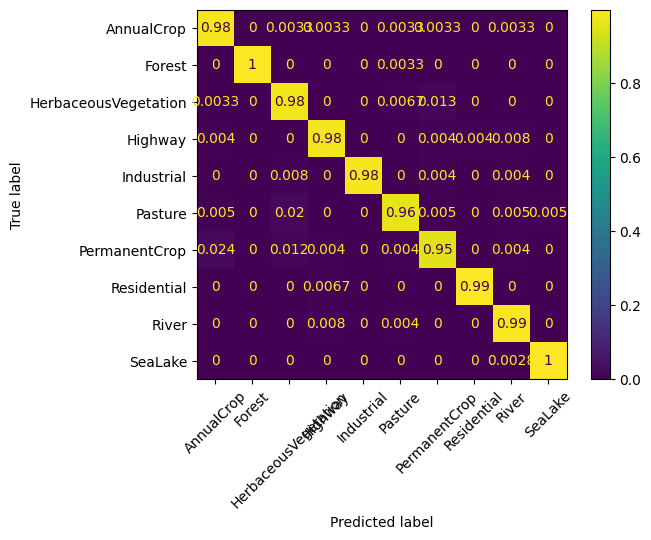

In [31]:
probs = predict(model,test_loader,device)
predicts = torch.argmax(probs,dim=1).cpu().numpy()
targets = torch.cat([l for _,l in test_loader]).cpu().numpy()
print(classification_report(targets, predicts, target_names=norm_test_dataset.classes, digits=4))
cm = confusion_matrix(targets, predicts, normalize="true")
ConfusionMatrixDisplay(cm, display_labels=norm_test_dataset.classes).plot(xticks_rotation=45)

I think results are very good for 4 layer convolutional network!

**Lets now try to train network only on RGB inputs:**

In [50]:
class SelectBands:
    def __init__(self, bands):
        self.bands = bands
    def __call__(self, img):          
        return img[self.bands]        

rgb_bands = [1, 2, 3]                  
rgb_mean  = mean[rgb_bands]           
rgb_std   = std[rgb_bands]

rgb_transform = transforms.Compose([
    SelectBands(rgb_bands),           
    transforms.Normalize(rgb_mean, rgb_std),   
])

In [51]:
root_rgb = "/kaggle/input/datasets/apollo2506/eurosat-dataset/EuroSATallBands"
label_map="/kaggle/input/datasets/apollo2506/eurosat-dataset/EuroSATallBands/label_map.json"
rgb_train_ds = EuroSATdataset("/kaggle/input/datasets/apollo2506/eurosat-dataset/EuroSATallBands/train.csv",root_rgb,label_map,transform=rgb_transform)
rgb_val_ds = EuroSATdataset("/kaggle/input/datasets/apollo2506/eurosat-dataset/EuroSATallBands/validation.csv",root_rgb,label_map,transform=rgb_transform)
rgb_test_ds = EuroSATdataset("/kaggle/input/datasets/apollo2506/eurosat-dataset/EuroSATallBands/test.csv",root_rgb,label_map,transform=rgb_transform)

rgb_train_loader = DataLoader(rgb_train_ds, batch_size=32, shuffle=True,  num_workers=4, pin_memory=True)
rgb_val_loader   = DataLoader(rgb_val_ds,   batch_size=32, shuffle=False, num_workers=4, pin_memory=True)
rgb_test_loader  = DataLoader(rgb_test_ds,  batch_size=32, shuffle=False, num_workers=4, pin_memory=True)

In [69]:
rgb_model = nn.Sequential()
rgb_model.append(nn.Conv2d(in_channels=3,out_channels=64,kernel_size=3,padding=1,bias=False))
rgb_model.append(nn.BatchNorm2d(num_features=64))
rgb_model.append(nn.ReLU())
rgb_model.append(nn.MaxPool2d(kernel_size=2,stride=2))
rgb_model.append(nn.Conv2d(in_channels=64,out_channels=128,kernel_size=3,padding=1,bias=False))
rgb_model.append(nn.BatchNorm2d(num_features=128))
rgb_model.append(nn.ReLU())
rgb_model.append(nn.MaxPool2d(kernel_size=2,stride=2))
rgb_model.append(nn.Conv2d(in_channels=128,out_channels=256,kernel_size=3,padding=1,bias=False))
rgb_model.append(nn.BatchNorm2d(num_features=256))
rgb_model.append(nn.ReLU())
rgb_model.append(nn.MaxPool2d(kernel_size=2,stride=2))
rgb_model.append(nn.Conv2d(in_channels=256,out_channels=512,kernel_size=3,padding=1,bias=False))
rgb_model.append(nn.BatchNorm2d(num_features=512))
rgb_model.append(nn.ReLU())
rgb_model.append(nn.MaxPool2d(kernel_size=2,stride=2))
rgb_model.append(nn.Flatten())
rgb_model.append(nn.Dropout(p=0.5))
rgb_model.append(nn.Linear(in_features=8192,out_features=10))

rgb_model = rgb_model.to(device)

In [70]:
rgb_optim = torch.optim.Adam(rgb_model.parameters(), lr=0.001)
rgb_scheduler = torch.optim.lr_scheduler.StepLR(rgb_optim, step_size=20, gamma=0.1)

In [71]:
rgb_results = train(
    rgb_model, rgb_optim, loss_fn,
    rgb_train_loader, rgb_val_loader,
    epochs=30, device=device,           
    scheduler=rgb_scheduler,
    checkpoint_path="/kaggle/working/rgb_checkpoint.pt",
    early_stopping_fn=early_stopping,
)

Model evaluation before start of training...




Starting epoch 1/30


Epoch: 1
Training   — loss: 0.6011, acc: 79.89%, F1: 0.7849
Validation — loss: 0.6567, acc: 78.93%, F1: 0.7749
Checkpoint saved with validation F1 0.7749


Starting epoch 2/30


Epoch: 2
Training   — loss: 0.5701, acc: 80.40%, F1: 0.7999
Validation — loss: 0.5983, acc: 79.62%, F1: 0.7922
Checkpoint saved with validation F1 0.7922


Starting epoch 3/30


Epoch: 3
Training   — loss: 0.3383, acc: 88.17%, F1: 0.8789
Validation — loss: 0.4006, acc: 86.79%, F1: 0.8641
Checkpoint saved with validation F1 0.8641


Starting epoch 4/30


...

Epoch: 24
Training   — loss: 0.0107, acc: 99.70%, F1: 0.9971
Validation — loss: 0.1238, acc: 96.41%, F1: 0.9631


Starting epoch 25/30


Epoch: 25
Training   — loss: 0.0079, acc: 99.80%, F1: 0.9980
Validation — loss: 0.1163, acc: 96.70%, F1: 0.9663


Starting epoch 26/30


Epoch: 26
Training   — loss: 0.0065, acc: 99.80%, F1: 0.9979
Validation — loss: 0.1242, acc: 96.88%, F1: 0.9676


Starting epoch 27/30


Epoch: 27
Training   — loss: 0.0063, acc: 99.84%, F1: 0.9984
Validation — loss: 0.1204, acc: 96.76%, F1: 0.9667


Starting epoch 28/30


Epoch: 28
Training   — loss: 0.0067, acc: 99.85%, F1: 0.9985
Validation — loss: 0.1153, acc: 96.83%, F1: 0.9675
Early stopping triggered after 28 epochs


In [78]:
ckpt_rgb = torch.load("/kaggle/working/rgb_checkpoint.pt")
rgb_model.load_state_dict(ckpt_rgb["model_state_dict"])
rgb_test_loss, rgb_test_acc, rgb_test_f1 = score(rgb_model, rgb_test_loader, loss_fn, device)
print(f"RGBTEST — acc: {rgb_test_acc*100:.2f}%, RGBmacro-F1: {rgb_test_f1:.4f}")

RGBTEST — acc: 97.28%, RGBmacro-F1: 0.9713


                      precision    recall  f1-score   support

          AnnualCrop     0.9604    0.9700    0.9652       300
              Forest     0.9739    0.9933    0.9835       300
HerbaceousVegetation     0.9507    0.9633    0.9570       300
             Highway     0.9722    0.9800    0.9761       250
          Industrial     0.9880    0.9880    0.9880       250
             Pasture     0.9691    0.9400    0.9543       200
       PermanentCrop     0.9518    0.9480    0.9499       250
         Residential     0.9867    0.9867    0.9867       300
               River     0.9711    0.9400    0.9553       250
             SeaLake     0.9972    0.9972    0.9972       359

            accuracy                         0.9728      2759
           macro avg     0.9721    0.9707    0.9713      2759
        weighted avg     0.9728    0.9728    0.9728      2759



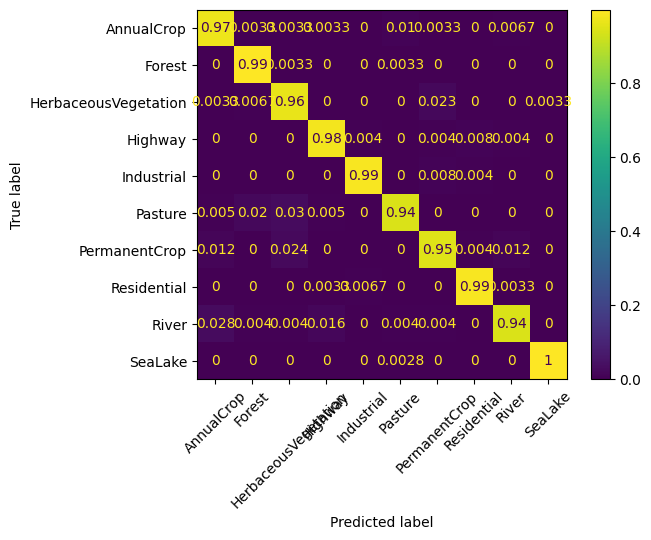

In [79]:
rgb_probs = predict(rgb_model,rgb_test_loader,device)
rgb_predicts = torch.argmax(rgb_probs,dim=1).cpu().numpy()
rgb_targets = torch.cat([l for _,l in rgb_test_loader]).cpu().numpy()
print(classification_report(rgb_targets, rgb_predicts, target_names=rgb_test_ds.classes, digits=4))
cm = confusion_matrix(rgb_targets, rgb_predicts, normalize="true")
ConfusionMatrixDisplay(cm, display_labels=rgb_test_ds.classes).plot(xticks_rotation=45)

In [80]:
print(f"13-band  — test acc: 98.26%, macro-F1: 0.9814")
print(f"RGB only — test acc: 97.28%, macro-F1: 0.9713")
print(f"Multispectral gain: +{(0.9814 - 0.9713):.4f} macro-F1")

13-band  — test acc: 98.26%, macro-F1: 0.9814
RGB only — test acc: 97.28%, macro-F1: 0.9713
Multispectral gain: +0.0101 macro-F1


In [83]:
f1_13  = f1_score(targets, predicts, average=None)   # your 13-band test preds
f1_rgb = f1_score(rgb_targets,    rgb_predicts,    average=None)    # your RGB test preds

delta = pd.DataFrame({
    "class": rgb_test_ds.classes,
    "f1_13band": f1_13,
    "f1_rgb":    f1_rgb,
    "gain":      f1_13 - f1_rgb,
}).sort_values("gain", ascending=False)
print(delta)

                  class  f1_13band    f1_rgb      gain
8                 River   0.980159  0.955285  0.024874
2  HerbaceousVegetation   0.971808  0.956954  0.014854
1                Forest   0.998331  0.983498  0.014832
0            AnnualCrop   0.976821  0.965174  0.011647
5               Pasture   0.964824  0.954315  0.010509
6         PermanentCrop   0.959677  0.949900  0.009778
7           Residential   0.994992  0.986667  0.008325
4            Industrial   0.991935  0.988000  0.003935
3               Highway   0.978044  0.976096  0.001948
9               SeaLake   0.997214  0.997214  0.000000


**Conclusion:**
The 13 spectral bands provide a small but consistent improvement (+~0.010 macro-F1),
with every class equal or better. The largest gain is on **River (+0.025)**: narrow
water features are visually ambiguous in RGB but unmistakable in the infrared bands,
where water's strong NIR absorption is distinctive. In contrast, **SeaLake** sees no
gain — large water bodies are already unambiguous in RGB. The benefit of multispectral
data thus concentrates where the visual signal is weak but the spectral signal is strong